In [1]:
# Step 1: Meat Price Prediction with XGBoost Regressor
# This script implements a machine learning pipeline using XGBRegressor.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

# ==========================================
# 1. Load and Inspect the Dataset
# ==========================================
df = pd.read_csv('meat_price_dataset.csv')
print(f'Dataset Shape: {df.shape}\n')
print(df.head())



Dataset Shape: (1200, 9)

   meat_type  fat_content_pct  protein_pct  marbling_score  animal_age_months  \
0          1             17.8         21.7               7                 49   
1          4             27.1         21.9               9                 22   
2          4             31.8         16.5               7                 20   
3          3             25.8         22.6               6                 11   
4          3             33.8         22.4               5                  2   

   storage_days  organic  cut_quality  price_eur_per_kg  
0            14        1            3             17.27  
1             4        0            4             29.69  
2             1        0            2             24.41  
3            16        0            2             15.08  
4            17        0            4             20.57  


In [2]:


# ==========================================
# 2. Exploratory Data Analysis & Feature Engineering
# ==========================================
# Check missing values and summary statistics
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSummary Statistics:")
print(df.describe())

# Feature engineering: Add protein-to-fat ratio to capture meat composition
df['protein_fat_ratio'] = df['protein_pct'] / (df['fat_content_pct'] + 1e-5)

# Split features (X) and target (y)
X = df.drop(columns=['price_eur_per_kg'])
y = df['price_eur_per_kg']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain set shape: {X_train.shape}, Test set shape: {X_test.shape}')




Missing Values:
meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
dtype: int64

Summary Statistics:
         meat_type  fat_content_pct  protein_pct  marbling_score  \
count  1200.000000      1200.000000  1200.000000     1200.000000   
mean      3.018333        18.686583    20.446667        5.329167   
std       1.415863         9.654055     3.182973        2.892425   
min       1.000000         2.000000    15.000000        1.000000   
25%       2.000000        10.100000    17.700000        3.000000   
50%       3.000000        18.300000    20.500000        5.000000   
75%       4.000000        27.500000    23.200000        8.000000   
max       5.000000        35.000000    26.000000       10.000000   

       animal_age_months  storage_days      organic  cut_quality  \
count        1200.000000   1200.000000  1200.000000  1200.000

In [3]:

# ==========================================
# 3. Train the XGBoost Regressor
# ==========================================
model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=5,
    random_state=42
)

# Fit the model to the training data
model.fit(X_train, y_train)



,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [4]:
# ==========================================
# 4. Evaluate Model Performance
# ==========================================
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

print('\n--- Model Performance ---')
print(f'Train RMSE: {np.sqrt(mean_squared_error(y_train, train_preds)):.4f}')
print(f'Test RMSE:  {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}')
print(f'Test MAE:   {mean_absolute_error(y_test, test_preds):.4f}')
print(f'Test R2:    {r2_score(y_test, test_preds):.4f}')


--- Model Performance ---
Train RMSE: 0.3869
Test RMSE:  1.2964
Test MAE:   1.0591
Test R2:    0.9751


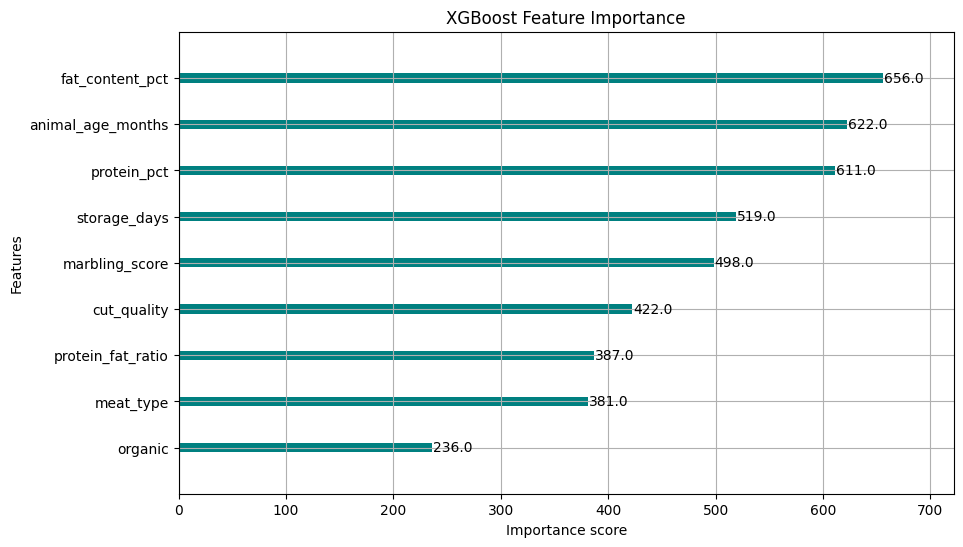

In [5]:
# ==========================================
# 5. Feature Importance Analysis
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, ax=ax, importance_type='weight', color='teal')
plt.title('XGBoost Feature Importance')
plt.show()

--- Stress Test Descriptive Statistics ---
       meat_type  fat_content_pct  protein_pct  marbling_score  \
count  91.000000        86.000000    90.000000       89.000000   
mean    3.109890        19.847674    20.394444        4.505618   
std     1.448758        11.311210     2.847406        2.545600   
min     1.000000         2.000000    15.100000        0.000000   
25%     2.000000        10.925000    18.100000        3.000000   
50%     3.000000        19.550000    20.150000        4.000000   
75%     4.000000        25.500000    22.850000        6.000000   
max     5.000000        58.500000    25.000000       12.000000   

       animal_age_months  storage_days    organic  cut_quality  \
count          92.000000     91.000000  91.000000    93.000000   
mean           38.891304     10.725275   0.263736     3.010753   
std            27.322436     11.664825   0.443099     1.418010   
min             2.000000      0.000000   0.000000     1.000000   
25%            18.750000      4.

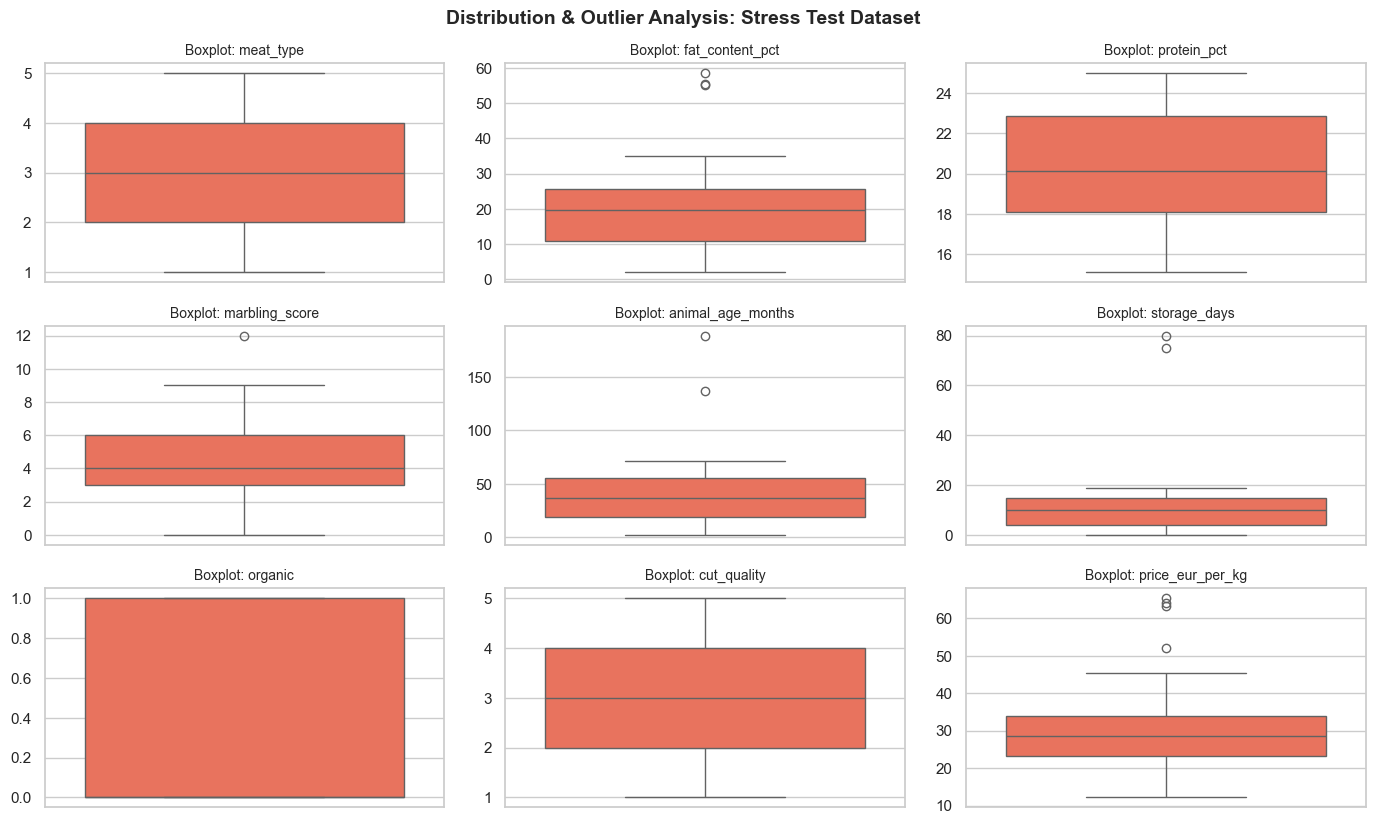

In [14]:
# Step 7: Descriptive Statistics and Boxplot Visualization for the Stress Test Set
# This script computes descriptive statistics and generates boxplots for all features in the stress test dataset.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load the Stress Test Dataset
# ==========================================
df_stress = pd.read_csv('meat_price_100_stress_test.csv')

# ==========================================
# 2. Compute and Display Descriptive Statistics
# ==========================================
print('--- Stress Test Descriptive Statistics ---')
desc_stats = df_stress.describe()
print(desc_stats)

# ==========================================
# 3. Generate Boxplots to Visualize Outliers
# ==========================================
# Set style and figure size
sns.set_theme(style='whitegrid')
plt.figure(figsize=(14, 8))

# Select numerical columns for boxplot visualization
numerical_cols = df_stress.select_dtypes(include=['float64', 'int64']).columns

# Create a melted dataframe for clean seaborn boxplotting, or plot subplots
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_stress[col], color='tomato')
    plt.title(f'Boxplot: {col}', fontsize=10)
    plt.ylabel('')

plt.tight_layout()
plt.suptitle('Distribution & Outlier Analysis: Stress Test Dataset', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [8]:
# ==========================================
# 6. Retrain or Load Model (Training Baseline)
# ==========================================
df_train = pd.read_csv('meat_price_dataset.csv')
df_train['protein_fat_ratio'] = df_train['protein_pct'] / (df_train['fat_content_pct'] + 1e-5)

X_train = df_train.drop(columns=['price_eur_per_kg'])
y_train = df_train['price_eur_per_kg']

# Initialize and train the XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [9]:
# ==========================================
# 6 a. Load and Inspect the Stress Test Dataset
# ==========================================
df_stress = pd.read_csv('meat_price_100_stress_test.csv')
print(f'Stress Test Shape: {df_stress.shape}\n')

print('Missing Values in Stress Test:')
print(df_stress.isnull().sum())

Stress Test Shape: (100, 9)

Missing Values in Stress Test:
meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64


In [10]:
# ==========================================
# 7. Handle Missing Values & Feature Engineering
# ==========================================
# Impute missing numerical values using training column medians or stress test medians
df_stress_imputed = df_stress.fillna(df_train.median())

# Apply the same feature engineering step (protein-to-fat ratio)
df_stress_imputed['protein_fat_ratio'] = df_stress_imputed['protein_pct'] / (df_stress_imputed['fat_content_pct'] + 1e-5)

# Separate features from target (if target 'price_eur_per_kg' is present in stress test)
if 'price_eur_per_kg' in df_stress_imputed.columns:
    X_stress = df_stress_imputed.drop(columns=['price_eur_per_kg'])
    y_stress_true = df_stress_imputed['price_eur_per_kg']
    has_target = True
else:
    X_stress = df_stress_imputed
    has_target = False

In [12]:
# ==========================================
# 8. Make Predictions on the Stress Test Set
# ==========================================
stress_preds = model.predict(X_stress)

# Attach predictions back to the dataframe for analysis
df_stress['predicted_price_eur_per_kg'] = stress_preds
print('\nSample Predictions:')
print(df_stress[['price_eur_per_kg', 'predicted_price_eur_per_kg']].head(50))


Sample Predictions:
    price_eur_per_kg  predicted_price_eur_per_kg
0              32.28                   27.033882
1              38.22                   33.668308
2              27.56                   16.654034
3              45.09                   28.937862
4                NaN                   33.592064
5              26.75                   17.850388
6              26.62                   19.440821
7              40.12                   35.411625
8              27.23                    8.826262
9              24.79                   23.346996
10             25.93                   28.950026
11             27.77                   25.400934
12             40.34                   33.776165
13             42.37                   14.850823
14             23.17                   18.332420
15             25.75                   18.347187
16             41.16                   30.373333
17               NaN                   31.982439
18             30.78                   17.839903

In [13]:
# ==========================================
# 5. Evaluate Performance (If True Prices Exist)
# ==========================================
if has_target:
    # Filter out rows where true price might be NaN in stress test
    valid_idx = ~y_stress_true.isnull()
    y_true_valid = y_stress_true[valid_idx]
    y_preds_valid = stress_preds[valid_idx]

    rmse = np.sqrt(mean_squared_error(y_true_valid, y_preds_valid))
    mae = mean_absolute_error(y_true_valid, y_preds_valid)
    r2 = r2_score(y_true_valid, y_preds_valid)

    print('\n--- Stress Test Performance Metrics ---')
    print(f'Stress Test RMSE: {rmse:.4f}')
    print(f'Stress Test MAE:  {mae:.4f}')
    print(f'Stress Test R2:   {r2:.4f}')


--- Stress Test Performance Metrics ---
Stress Test RMSE: 11.1558
Stress Test MAE:  8.7577
Stress Test R2:   -0.3590
